<a href="https://colab.research.google.com/github/MuhamadRizki10R2/ML-Love-Interest-Prediction/blob/main/model_Predict_Cinta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project ML - Model Prediksi Seseorang suka lewat Chattingan pake XGBoost

## 1. Install dan Import Library

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Colab Notebooks/dataset/prediksiSukaSeseorang/dataset_chat_suka_advanced_200rows.csv";
df = pd.read_csv(path)

df.head()

Mounted at /content/drive


,avg_reply_time,chat_freq,msg_length,emoji_ratio,question_ratio,response_consistency,suka,sentiment_score,response_delay_variance,first_message_ratio,night_chat_ratio,initiator_ratio,reply_depth,conversation_entropy,topic_similarity
0,22.79,24,94,0.71,0.74,0.43,1,-0.251,19.26,0.10,0.17,0.71,12,1.611,0.817
1,57.07,11,52,0.25,0.56,0.80,0,0.901,2.52,0.90,0.28,0.15,14,1.779,0.452
2,44.05,49,89,0.33,0.59,0.35,1,0.464,4.85,0.51,0.18,0.58,8,1.740,0.644
3,36.12,8,43,0.43,0.56,0.47,1,0.197,26.96,0.83,0.09,0.61,3,0.274,0.526
4,9.78,36,104,0.25,0.38,0.62,1,-0.688,18.19,0.32,0.12,0.42,8,2.632,0.732


## 3. Feature & Target

In [ ]:
X = df.drop(columns=["suka"])
y = df["suka"]

## 4. Split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Scalling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Training Model

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

## 7. Evaluation Model

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("AUC:", auc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.575
AUC: 0.5858585858585859

Confusion Matrix:
 [[ 6 12]
 [ 5 17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.33      0.41        18
           1       0.59      0.77      0.67        22

    accuracy                           0.57        40
   macro avg       0.57      0.55      0.54        40
weighted avg       0.57      0.57      0.55        40



## 8. Hyperparameter tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best AUC Score:", random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.011413261043943482), 'max_depth': 3, 'n_estimators': 148, 'subsample': np.float64(0.8099098641033556)}
Best AUC Score: 0.5225770308123249


## 9. Visualization Data

### A. Visualisasi 1 — Feature Importance

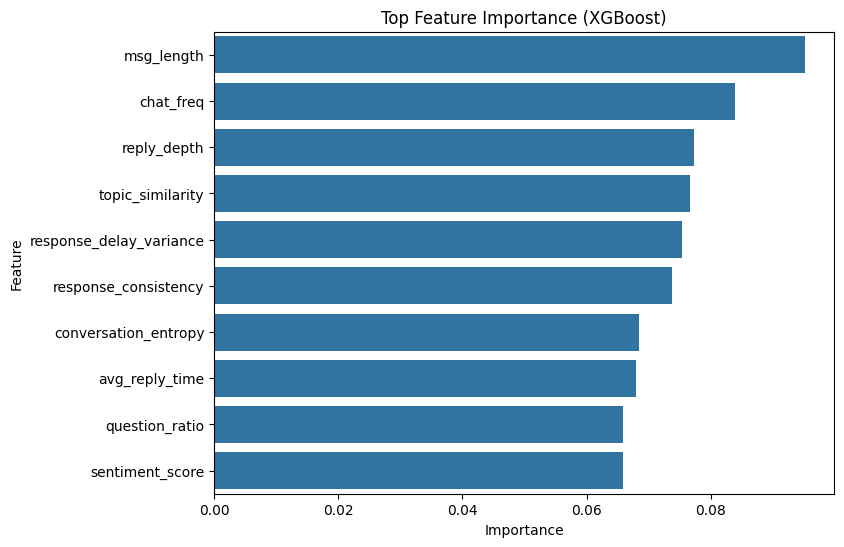

In [ ]:
importances = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=imp_df.head(10), x="Importance", y="Feature")
plt.title("Top Feature Importance (XGBoost)")
plt.show()

### B. Visualisasi 2 — ROC Curve

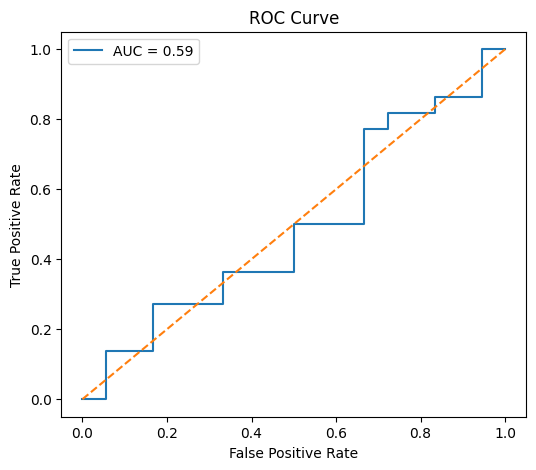

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### C. Visualisasi 3 — Probability Separation

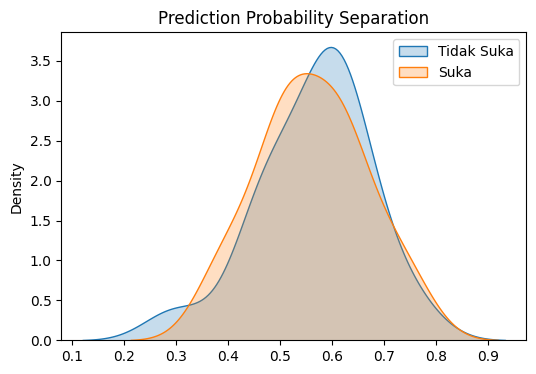

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(y_prob[y_test==0], label="Tidak Suka", fill=True)
sns.kdeplot(y_prob[y_test==1], label="Suka", fill=True)
plt.title("Prediction Probability Separation")
plt.legend()
plt.show()

## 10. Predict New Chat Pattern

In [ ]:
new_data = np.array([[
    40, 12, 0.3, 0.8, 0.4, 15,
    0.7, 10, 0.6, 0.4, 0.5, 7, 1.2, 0.65
]])

new_scaled = scaler.transform(new_data)

prob = model.predict_proba(new_scaled)
pred = model.predict(new_scaled)

print("Probabilitas suka:", prob)
print("Prediksi:", pred)

Probabilitas suka: [[0.593897   0.40610304]]
Prediksi: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
